In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import models, layers,datasets

In [29]:
np.random.seed(42)
tf.random.set_seed(42)

In [30]:
(X_train,y_train),(X_test,y_test) = datasets.mnist.load_data()

In [31]:
X_train.shape

(60000, 28, 28)

In [32]:
X_test.shape

(10000, 28, 28)

In [33]:
y_train[:10]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4], dtype=uint8)

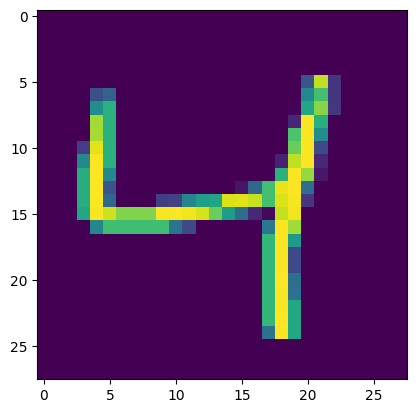

In [34]:
plt.imshow(X_train[2])

In [35]:
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation="relu"),            #ANN
    layers.Dense(10, activation="softmax")
])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [36]:
model.fit(X_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8657 - loss: 2.7155
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9114 - loss: 0.4042
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9313 - loss: 0.2763
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9401 - loss: 0.2433
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9448 - loss: 0.2253


In [37]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9417 - loss: 0.2628


[0.262844055891037, 0.9416999816894531]

In [38]:
#model evaluation

from sklearn.metrics import confusion_matrix,classification_report

y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [39]:
y_predicted = [np.argmax(i) for i in y_pred]

In [40]:
confusion_matrix(y_test, y_predicted)

array([[ 957,    0,    1,    0,    1,    0,   11,    2,    8,    0],
       [   0, 1117,    2,    3,    0,    1,    5,    1,    5,    1],
       [   8,    4,  938,    2,    3,    0,    3,   60,   14,    0],
       [   2,    3,   18,  936,    0,    8,    0,    9,   24,   10],
       [   5,    3,    9,    0,  904,    0,    4,    5,    5,   47],
       [   4,    2,    0,   30,    1,  786,   34,    4,   23,    8],
       [   4,    3,    2,    2,    3,    5,  932,    0,    7,    0],
       [   2,    1,   15,    6,    4,    1,    1,  977,    3,   18],
       [   2,    3,   10,    3,    4,    3,    9,    7,  921,   12],
       [   6,    6,    0,   11,   14,    2,    1,    9,   11,  949]])

In [41]:
print(classification_report(y_test,y_predicted))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       980
           1       0.98      0.98      0.98      1135
           2       0.94      0.91      0.93      1032
           3       0.94      0.93      0.93      1010
           4       0.97      0.92      0.94       982
           5       0.98      0.88      0.93       892
           6       0.93      0.97      0.95       958
           7       0.91      0.95      0.93      1028
           8       0.90      0.95      0.92       974
           9       0.91      0.94      0.92      1009

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



In [46]:
cnn = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3,3), input_shape=(28, 28, 1), activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [47]:
cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [48]:
cnn.fit(X_train,y_train,epochs = 5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 26ms/step - accuracy: 0.9475 - loss: 0.3339
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 26ms/step - accuracy: 0.9814 - loss: 0.0642
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 25ms/step - accuracy: 0.9845 - loss: 0.0500
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 49s 26ms/step - accuracy: 0.9877 - loss: 0.0404
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 26ms/step - accuracy: 0.9898 - loss: 0.0325


In [49]:
cnn.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9838 - loss: 0.0623


[0.062319885939359665, 0.9837999939918518]

In [ ]:
y_pred

In [50]:
y_pred = cnn.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


In [52]:
y_predic = [np.argmax(i) for i in y_pred]

In [55]:
cm = classification_report(y_test,y_predic)

<Axes: >

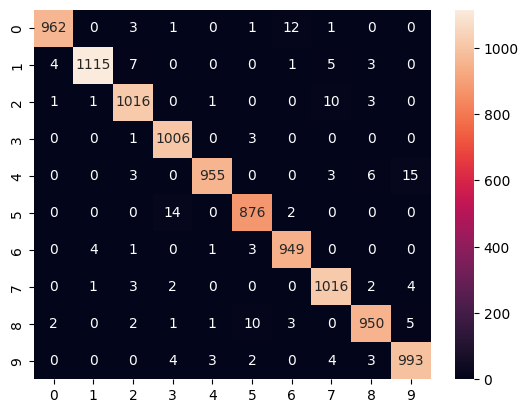

In [58]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_array = confusion_matrix(y_test, y_predic)

sns.heatmap(cm_array, annot=True, fmt='d')